In [3]:
!pip install vaderSentiment scipy -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
import os
import re
import warnings
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')

SAVE_PATH     = "/content/drive/MyDrive/"
OUTPUT_PATH   = "/content/drive/MyDrive/figures/"
LABELLED_PATH = "/content/drive/MyDrive/Original Reddit Data/Labelled Data"
os.makedirs(OUTPUT_PATH, exist_ok=True)

analyzer  = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

def classify_sentiment(compound):
    if compound >= 0.05:   return 'Positive'
    elif compound <= -0.05: return 'Negative'
    else:                   return 'Neutral'

def clean_for_vader(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Load yearly VADER results ──────────────────────
print("Loading yearly results...")
dfs = []
for year in ['2019', '2020', '2021', '2022']:
    fp = SAVE_PATH + f"vader_{year}.csv"
    if os.path.exists(fp):
        temp = pd.read_csv(fp)
        print(f"  ✓ {year}: {temp.shape[0]:,} rows")
        dfs.append(temp)
    else:
        print(f"  ✗ {year}: NOT FOUND")

df_results = pd.concat(dfs, ignore_index=True)
del dfs
print(f"\nTotal: {df_results.shape[0]:,} rows")

# ── Load Part B ────────────────────────────────────
print("\nLoading Part B...")
label_files = {
    "Drug and Alcohol" : LABELLED_PATH + "/LD DA 1.csv",
    "Early Life"       : LABELLED_PATH + "/LD EL1.csv",
    "Personality"      : LABELLED_PATH + "/LD PF1.csv",
    "Trauma and Stress": LABELLED_PATH + "/LD TS 1.csv"
}

dfs_b = []
for label, filepath in label_files.items():
    try:
        temp = pd.read_csv(filepath)
        temp['Label'] = label
        dfs_b.append(temp)
        print(f"  ✓ {label}: {temp.shape[0]} rows")
    except Exception as e:
        print(f"  ✗ {label}: {e}")

df_b = pd.concat(dfs_b, ignore_index=True)
df_b = df_b.dropna(subset=['selftext'])
if 'CAT 1' in df_b.columns:
    df_b = df_b.drop(columns=['CAT 1'])
df_b['full_text']  = df_b['title'].fillna('') + ' ' + df_b['selftext'].fillna('')
df_b['vader_text'] = df_b['full_text'].apply(clean_for_vader)

print(f"\nPart B: {df_b.shape[0]} rows")
print("\n✅ Everything loaded — ready for charts")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.3 MB/s eta 0:00:0000:01
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading yearly results...
  ✓ 2019: 284,993 rows
  ✓ 2020: 335,368 rows
  ✓ 2021: 477,714 rows
  ✓ 2022: 314,711 rows

Total: 1,412,786 rows

Loading Part B...
  ✓ Drug and Alcohol: 223 rows
  ✓ Early Life: 200 rows
  ✓ Personality: 200 rows
  ✓ Trauma and Stress: 200 rows

Part B: 800 rows

✅ Everything loaded — ready for charts


In [2]:
!pip install vaderSentiment scipy -q
!pip install nltk -q

import nltk
nltk.download('stopwords', quiet=True)

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# ── Paths ──────────────────────────────────────────
BASE_PATH   = "/content/drive/MyDrive/Original Reddit Data"
RAW_PATH    = os.path.join(BASE_PATH, "raw data")
SAVE_PATH   = "/content/drive/MyDrive/"
OUTPUT_PATH = "/content/drive/MyDrive/figures/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── VADER ──────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()

# ── Valid subreddits ───────────────────────────────
valid_subreddits = [
    'depression', 'SuicideWatch',
    'mentalhealth', 'Anxiety', 'lonely'
]

# ── Cleaning function ──────────────────────────────
def clean_for_vader(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Classify sentiment ─────────────────────────────
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

print("Setup complete")
print(f"Years available: {os.listdir(RAW_PATH)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete
Years available: ['2022', '2019', '2021', '2020']


In [3]:
# ── Load Part B ────────────────────────────────────
LABELLED_PATH = "/content/drive/MyDrive/Original Reddit Data/Labelled Data"

label_files = {
    "Drug and Alcohol" : LABELLED_PATH + "/LD DA 1.csv",
    "Early Life"       : LABELLED_PATH + "/LD EL1.csv",
    "Personality"      : LABELLED_PATH + "/LD PF1.csv",
    "Trauma and Stress": LABELLED_PATH + "/LD TS 1.csv"
}

dfs_b = []
for label, filepath in label_files.items():
    try:
        temp = pd.read_csv(filepath)
        temp['Label'] = label
        dfs_b.append(temp)
        print(f"✓ {label}: {temp.shape[0]} rows")
    except Exception as e:
        print(f"✗ {label}: {e}")

df_b = pd.concat(dfs_b, ignore_index=True)
df_b = df_b.dropna(subset=['selftext'])
if 'CAT 1' in df_b.columns:
    df_b = df_b.drop(columns=['CAT 1'])

df_b['full_text']  = df_b['title'].fillna('') + ' ' + df_b['selftext'].fillna('')
df_b['vader_text'] = df_b['full_text'].apply(clean_for_vader)

print(f"\nPart B loaded: {df_b.shape[0]} rows")
print(f"Labels: {df_b['Label'].value_counts().to_dict()}")

✓ Drug and Alcohol: 223 rows
✓ Early Life: 200 rows
✓ Personality: 200 rows
✓ Trauma and Stress: 200 rows

Part B loaded: 800 rows
Labels: {'Drug and Alcohol': 200, 'Early Life': 200, 'Personality': 200, 'Trauma and Stress': 200}


In [4]:
# ── Test VADER before running on full data ─────────
test_posts = [
    "I feel so hopeless and empty inside nothing helps",
    "Today was okay just getting through the day",
    "I finally got out of bed today small win",
    "I cant stop crying I dont want to be here anymore"
]

print("=== VADER TEST ===\n")
print(f"{'Post':<48} {'Neg':>6} {'Neu':>6} {'Pos':>6} {'Compound':>10} {'Label':>10}")
print("-" * 95)

for post in test_posts:
    scores = analyzer.polarity_scores(post)
    label  = classify_sentiment(scores['compound'])
    print(f"{post[:47]:<48} {scores['neg']:>6.3f} {scores['neu']:>6.3f} {scores['pos']:>6.3f} {scores['compound']:>10.3f} {label:>10}")

=== VADER TEST ===

Post                                                Neg    Neu    Pos   Compound      Label
-----------------------------------------------------------------------------------------------
I feel so hopeless and empty inside nothing hel   0.575  0.425  0.000     -0.797   Negative
Today was okay just getting through the day       0.000  0.787  0.213      0.226   Positive
I finally got out of bed today small win          0.000  0.678  0.322      0.586   Positive
I cant stop crying I dont want to be here anymo   0.089  0.585  0.325      0.497   Positive


In [5]:
# ── Process 2019 ───────────────────────────────────
import time
all_results = []

year = '2019'
year_path = os.path.join(RAW_PATH, year)

print(f"Processing {year}...")
year_files = glob.glob(
    os.path.join(year_path, "**", "*.csv"),
    recursive=True
)
print(f"Files: {len(year_files)}")

dfs = []
for f in year_files:
    try:
        temp = pd.read_csv(f, low_memory=False)
        dfs.append(temp)
    except:
        pass

df_year = pd.concat(dfs, ignore_index=True)
del dfs

df_year = df_year[df_year['subreddit'].isin(valid_subreddits)]
df_year = df_year[~df_year['selftext'].isin(['[deleted]', '[removed]'])]
df_year = df_year.dropna(subset=['selftext'])
df_year = df_year[df_year['selftext'].str.len() >= 10]
df_year['date']       = pd.to_datetime(df_year['created_utc'], unit='s')
df_year['year']       = df_year['date'].dt.year
df_year['month']      = df_year['date'].dt.month
df_year['full_text']  = df_year['title'].fillna('') + ' ' + df_year['selftext'].fillna('')
df_year['vader_text'] = df_year['full_text'].apply(clean_for_vader)

print(f"Clean rows: {df_year.shape[0]:,}")

scores = df_year['vader_text'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))
)
df_year['vader_compound']  = scores.apply(lambda x: x['compound'])
df_year['vader_neg']       = scores.apply(lambda x: x['neg'])
df_year['vader_pos']       = scores.apply(lambda x: x['pos'])
df_year['vader_sentiment'] = df_year['vader_compound'].apply(classify_sentiment)

results_2019 = df_year[[
    'subreddit', 'score', 'year', 'month',
    'vader_compound', 'vader_neg',
    'vader_pos', 'vader_sentiment'
]].copy()

print(f"Sentiment 2019:")
print(df_year['vader_sentiment'].value_counts())

del df_year, scores

# Save immediately
results_2019.to_csv(SAVE_PATH + "vader_2019.csv", index=False)
print(f"✓ vader_2019.csv saved")

Processing 2019...
Files: 51
Clean rows: 284,993
Sentiment 2019:
vader_sentiment
Negative    184837
Positive     95040
Neutral       5116
Name: count, dtype: int64
✓ vader_2019.csv saved


In [6]:
# ── Process 2020 ───────────────────────────────────
year = '2020'
year_path = os.path.join(RAW_PATH, year)

print(f"Processing {year}...")
year_files = glob.glob(
    os.path.join(year_path, "**", "*.csv"),
    recursive=True
)
print(f"Files: {len(year_files)}")

dfs = []
for f in year_files:
    try:
        temp = pd.read_csv(f, low_memory=False)
        dfs.append(temp)
    except:
        pass

df_year = pd.concat(dfs, ignore_index=True)
del dfs

df_year = df_year[df_year['subreddit'].isin(valid_subreddits)]
df_year = df_year[~df_year['selftext'].isin(['[deleted]', '[removed]'])]
df_year = df_year.dropna(subset=['selftext'])
df_year = df_year[df_year['selftext'].str.len() >= 10]
df_year['date']       = pd.to_datetime(df_year['created_utc'], unit='s')
df_year['year']       = df_year['date'].dt.year
df_year['month']      = df_year['date'].dt.month
df_year['full_text']  = df_year['title'].fillna('') + ' ' + df_year['selftext'].fillna('')
df_year['vader_text'] = df_year['full_text'].apply(clean_for_vader)

print(f"Clean rows: {df_year.shape[0]:,}")

scores = df_year['vader_text'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))
)
df_year['vader_compound']  = scores.apply(lambda x: x['compound'])
df_year['vader_neg']       = scores.apply(lambda x: x['neg'])
df_year['vader_pos']       = scores.apply(lambda x: x['pos'])
df_year['vader_sentiment'] = df_year['vader_compound'].apply(classify_sentiment)

results_2020 = df_year[[
    'subreddit', 'score', 'year', 'month',
    'vader_compound', 'vader_neg',
    'vader_pos', 'vader_sentiment'
]].copy()

print(f"Sentiment 2020:")
print(df_year['vader_sentiment'].value_counts())

del df_year, scores

results_2020.to_csv(SAVE_PATH + "vader_2020.csv", index=False)
print(f"✓ vader_2020.csv saved")

Processing 2020...
Files: 47
Clean rows: 335,368
Sentiment 2020:
vader_sentiment
Negative    217506
Positive    111650
Neutral       6212
Name: count, dtype: int64
✓ vader_2020.csv saved


In [7]:
# ── Process 2021 ───────────────────────────────────
year = '2021'
year_path = os.path.join(RAW_PATH, year)

print(f"Processing {year}...")
year_files = glob.glob(
    os.path.join(year_path, "**", "*.csv"),
    recursive=True
)
print(f"Files: {len(year_files)}")

dfs = []
for f in year_files:
    try:
        temp = pd.read_csv(f, low_memory=False)
        dfs.append(temp)
    except:
        pass

df_year = pd.concat(dfs, ignore_index=True)
del dfs

df_year = df_year[df_year['subreddit'].isin(valid_subreddits)]
df_year = df_year[~df_year['selftext'].isin(['[deleted]', '[removed]'])]
df_year = df_year.dropna(subset=['selftext'])
df_year = df_year[df_year['selftext'].str.len() >= 10]
df_year['date']       = pd.to_datetime(df_year['created_utc'], unit='s')
df_year['year']       = df_year['date'].dt.year
df_year['month']      = df_year['date'].dt.month
df_year['full_text']  = df_year['title'].fillna('') + ' ' + df_year['selftext'].fillna('')
df_year['vader_text'] = df_year['full_text'].apply(clean_for_vader)

print(f"Clean rows: {df_year.shape[0]:,}")

scores = df_year['vader_text'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))
)
df_year['vader_compound']  = scores.apply(lambda x: x['compound'])
df_year['vader_neg']       = scores.apply(lambda x: x['neg'])
df_year['vader_pos']       = scores.apply(lambda x: x['pos'])
df_year['vader_sentiment'] = df_year['vader_compound'].apply(classify_sentiment)

results_2021 = df_year[[
    'subreddit', 'score', 'year', 'month',
    'vader_compound', 'vader_neg',
    'vader_pos', 'vader_sentiment'
]].copy()

print(f"Sentiment 2021:")
print(df_year['vader_sentiment'].value_counts())

del df_year, scores

results_2021.to_csv(SAVE_PATH + "vader_2021.csv", index=False)
print(f"✓ vader_2021.csv saved")


Processing 2021...
Files: 57
Clean rows: 477,714
Sentiment 2021:
vader_sentiment
Negative    309325
Positive    159023
Neutral       9366
Name: count, dtype: int64
✓ vader_2021.csv saved


In [8]:
# ── Process 2022 ───────────────────────────────────
year = '2022'
year_path = os.path.join(RAW_PATH, year)

print(f"Processing {year}...")
year_files = glob.glob(
    os.path.join(year_path, "**", "*.csv"),
    recursive=True
)
print(f"Files: {len(year_files)}")

dfs = []
for f in year_files:
    try:
        temp = pd.read_csv(f, low_memory=False)
        dfs.append(temp)
    except:
        pass

df_year = pd.concat(dfs, ignore_index=True)
del dfs

df_year = df_year[df_year['subreddit'].isin(valid_subreddits)]
df_year = df_year[~df_year['selftext'].isin(['[deleted]', '[removed]'])]
df_year = df_year.dropna(subset=['selftext'])
df_year = df_year[df_year['selftext'].str.len() >= 10]
df_year['date']       = pd.to_datetime(df_year['created_utc'], unit='s')
df_year['year']       = df_year['date'].dt.year
df_year['month']      = df_year['date'].dt.month
df_year['full_text']  = df_year['title'].fillna('') + ' ' + df_year['selftext'].fillna('')
df_year['vader_text'] = df_year['full_text'].apply(clean_for_vader)

print(f"Clean rows: {df_year.shape[0]:,}")

scores = df_year['vader_text'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))
)
df_year['vader_compound']  = scores.apply(lambda x: x['compound'])
df_year['vader_neg']       = scores.apply(lambda x: x['neg'])
df_year['vader_pos']       = scores.apply(lambda x: x['pos'])
df_year['vader_sentiment'] = df_year['vader_compound'].apply(classify_sentiment)

results_2022 = df_year[[
    'subreddit', 'score', 'year', 'month',
    'vader_compound', 'vader_neg',
    'vader_pos', 'vader_sentiment'
]].copy()

print(f"Sentiment 2022:")
print(df_year['vader_sentiment'].value_counts())

del df_year, scores

results_2022.to_csv(SAVE_PATH + "vader_2022.csv", index=False)
print(f"✓ vader_2022.csv saved")

Processing 2022...
Files: 39
Clean rows: 314,711
Sentiment 2022:
vader_sentiment
Negative    202180
Positive    106135
Neutral       6396
Name: count, dtype: int64
✓ vader_2022.csv saved


In [9]:
# ── Combine all yearly results ─────────────────────
print("Combining all years...")

yearly_files = {
    '2019': SAVE_PATH + "vader_2019.csv",
    '2020': SAVE_PATH + "vader_2020.csv",
    '2021': SAVE_PATH + "vader_2021.csv",
    '2022': SAVE_PATH + "vader_2022.csv"
}

dfs = []
for year, filepath in yearly_files.items():
    if os.path.exists(filepath):
        temp = pd.read_csv(filepath)
        print(f"  {year}: {temp.shape[0]:,} rows")
        dfs.append(temp)
    else:
        print(f"  {year}: file not found")

df_results = pd.concat(dfs, ignore_index=True)
del dfs

print(f"\nTotal combined: {df_results.shape[0]:,} rows")
print(f"\nOverall sentiment:")
print(df_results['vader_sentiment'].value_counts())
print(f"\nPercentages:")
print(df_results['vader_sentiment'].value_counts(
    normalize=True).mul(100).round(1))

# Save combined
df_results.to_csv(SAVE_PATH + "vader_results.csv", index=False)
print(f"\n✓ vader_results.csv saved")

Combining all years...
  2019: 284,993 rows
  2020: 335,368 rows
  2021: 477,714 rows
  2022: 314,711 rows

Total combined: 1,412,786 rows

Overall sentiment:
vader_sentiment
Negative    913848
Positive    471848
Neutral      27090
Name: count, dtype: int64

Percentages:
vader_sentiment
Negative    64.7
Positive    33.4
Neutral      1.9
Name: proportion, dtype: float64

✓ vader_results.csv saved


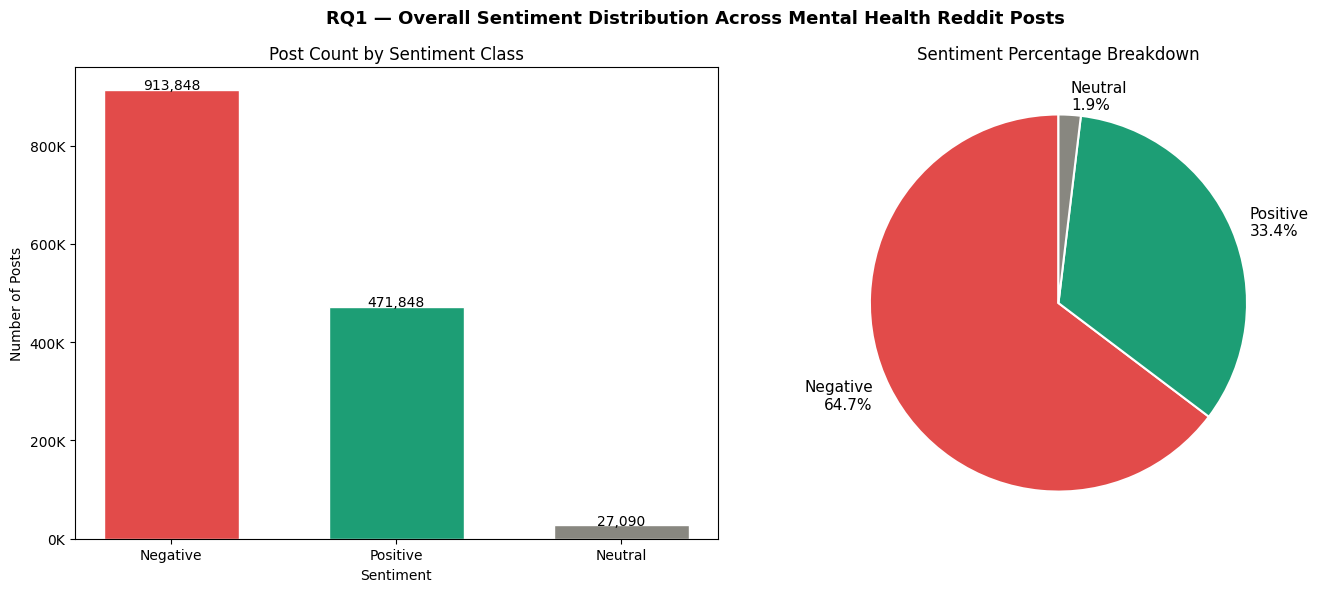

✓ Chart saved
Key finding: 64.7% negative


In [ ]:
# RQ1 Chart 1: Overall Sentiment
colors = {
    'Negative': '#E24B4A',
    'Neutral' : '#888780',
    'Positive': '#1D9E75'
}

sentiment_counts = df_results['vader_sentiment'].value_counts()
sentiment_pct    = df_results['vader_sentiment'].value_counts(
    normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'RQ1 — Overall Sentiment Distribution Across Mental Health Reddit Posts',
    fontsize=13, fontweight='bold'
)

bars = axes[0].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[colors[s] for s in sentiment_counts.index],
    edgecolor='white', width=0.6
)
axes[0].set_title('Post Count by Sentiment Class', fontsize=12)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Posts')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)
for bar, val in zip(bars, sentiment_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1000,
        f'{val:,}', ha='center', fontsize=10
    )

axes[1].pie(
    sentiment_pct.values,
    labels=[
        f"{s}\n{p}%"
        for s, p in zip(sentiment_pct.index, sentiment_pct.values)
    ],
    colors=[colors[s] for s in sentiment_pct.index],
    startangle=90,
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Sentiment Percentage Breakdown', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq1_overall_sentiment.png",
            dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart saved")
print(f"Key finding: {sentiment_pct.get('Negative', 0)}% negative")

Sentiment % by subreddit:
vader_sentiment  Negative  Neutral  Positive
subreddit                                   
SuicideWatch         72.6      2.3      25.0
depression           66.2      1.7      32.1
Anxiety              65.3      1.4      33.4
mentalhealth         60.8      1.7      37.5
lonely               43.1      2.9      54.0


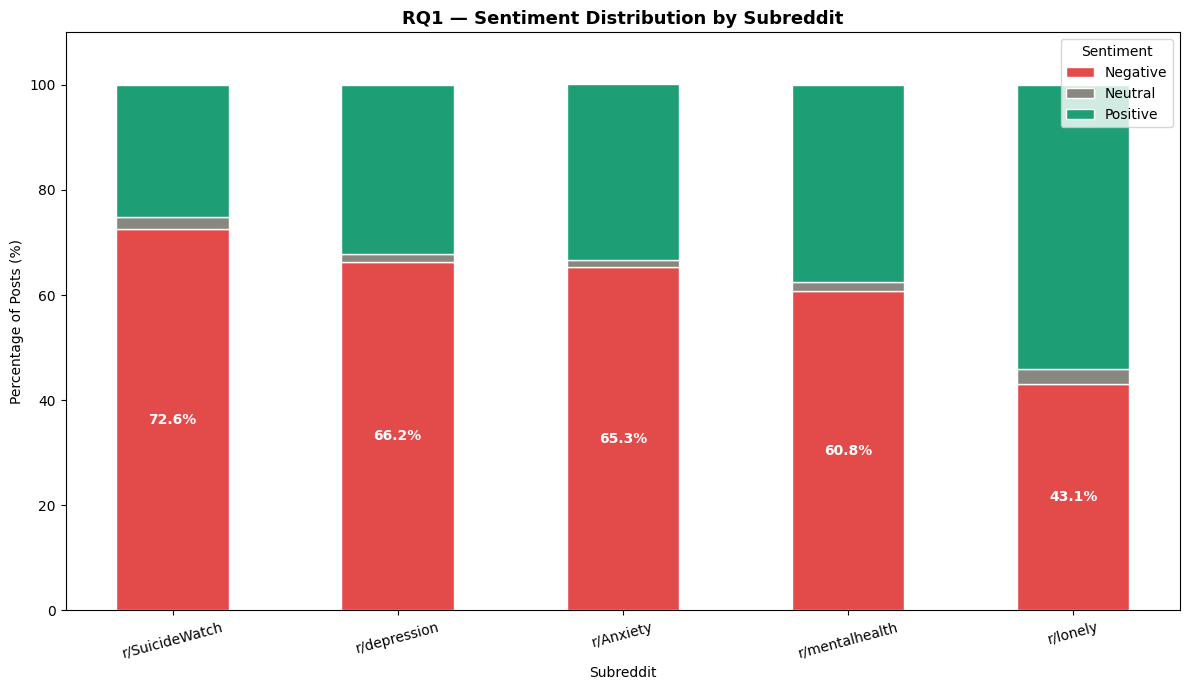

✓ Chart saved


In [ ]:
# RQ1 Chart 2: By Subreddit
subreddit_sentiment = df_results.groupby(
    ['subreddit', 'vader_sentiment']
).size().unstack(fill_value=0)

subreddit_pct = subreddit_sentiment.div(
    subreddit_sentiment.sum(axis=1), axis=0
).mul(100).round(1)

subreddit_pct = subreddit_pct.sort_values('Negative', ascending=False)

print("Sentiment % by subreddit:")
print(subreddit_pct)

fig, ax = plt.subplots(figsize=(12, 7))
subreddits = subreddit_pct.index.tolist()
x = range(len(subreddits))

neg_vals = subreddit_pct['Negative'].values
neu_vals = subreddit_pct['Neutral'].values
pos_vals = subreddit_pct['Positive'].values

ax.bar(x, neg_vals, 0.5, label='Negative',
       color='#E24B4A', edgecolor='white')
ax.bar(x, neu_vals, 0.5, bottom=neg_vals,
       label='Neutral', color='#888780', edgecolor='white')
ax.bar(x, pos_vals, 0.5, bottom=neg_vals + neu_vals,
       label='Positive', color='#1D9E75', edgecolor='white')

for i, val in enumerate(neg_vals):
    ax.text(i, val/2, f'{val}%',
            ha='center', va='center',
            color='white', fontsize=10, fontweight='bold')

ax.set_title('RQ1 — Sentiment Distribution by Subreddit',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Percentage of Posts (%)')
ax.set_xticks(list(x))
ax.set_xticklabels([f"r/{s}" for s in subreddits], rotation=15)
ax.legend(title='Sentiment')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq1_by_subreddit.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

Sentiment % by year:
vader_sentiment  Negative  Neutral  Positive
year                                        
2018                 61.1      3.1      35.8
2019                 64.8      1.8      33.4
2020                 64.9      1.9      33.3
2021                 64.7      2.0      33.3
2022                 64.3      2.0      33.7


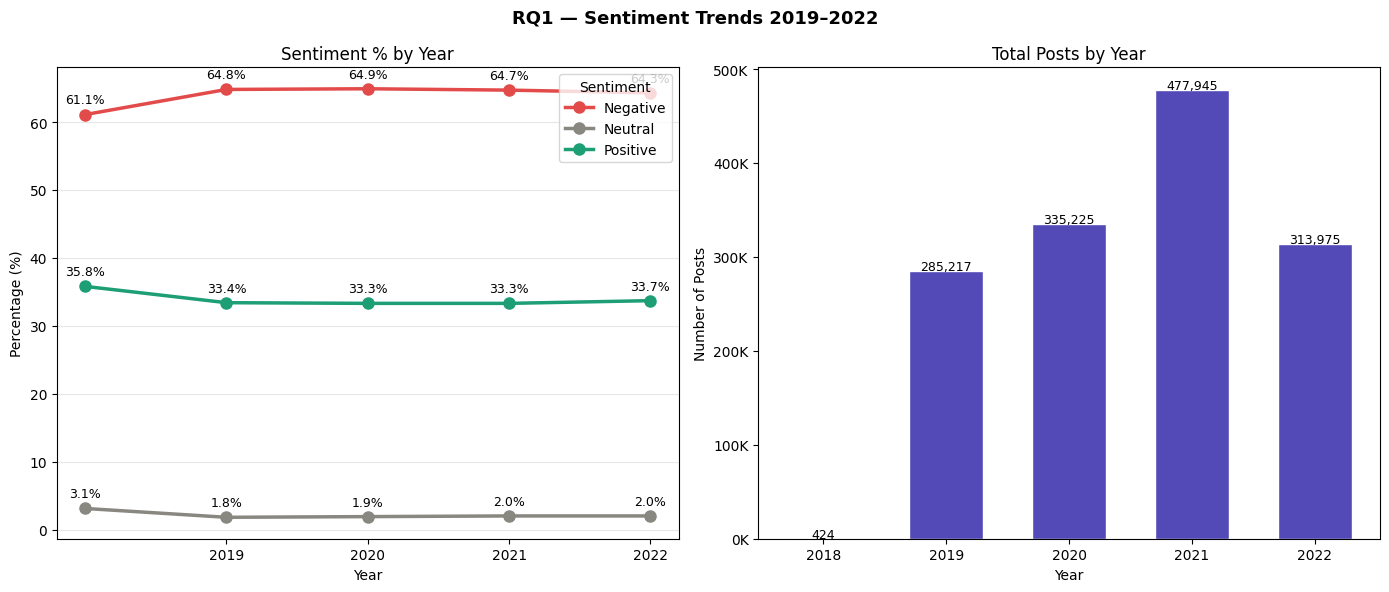

✓ Chart saved


In [9]:
# RQ1 Chart 3: Over Time
df_results['year'] = df_results['year'].astype(int)

yearly = df_results.groupby(
    ['year', 'vader_sentiment']
).size().unstack(fill_value=0)

yearly_pct = yearly.div(
    yearly.sum(axis=1), axis=0
).mul(100).round(1)

print("Sentiment % by year:")
print(yearly_pct)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQ1 — Sentiment Trends 2019–2022',
             fontsize=13, fontweight='bold')

for sentiment, color in colors.items():
    if sentiment in yearly_pct.columns:
        axes[0].plot(
            yearly_pct.index, yearly_pct[sentiment],
            marker='o', linewidth=2.5,
            markersize=8, color=color, label=sentiment
        )
        for year, val in zip(
            yearly_pct.index, yearly_pct[sentiment]
        ):
            axes[0].annotate(
                f'{val}%', (year, val),
                textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=9
            )

axes[0].set_title('Sentiment % by Year', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Sentiment')
axes[0].set_xticks([2019, 2020, 2021, 2022])
axes[0].grid(axis='y', alpha=0.3)

yearly_total = df_results.groupby('year').size()
axes[1].bar(
    yearly_total.index, yearly_total.values,
    color='#534AB7', edgecolor='white', width=0.6
)
axes[1].set_title('Total Posts by Year', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Posts')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)
for year, val in yearly_total.items():
    axes[1].text(
        year, val + 500, f'{val:,}',
        ha='center', fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq1_over_time.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

=== RQ2: ENGAGEMENT ANALYSIS ===

Engagement stats by sentiment:
                  count  mean  median
vader_sentiment                      
Negative         913848  2.57     1.0
Neutral           27090  2.55     1.0
Positive         471848  2.97     1.0

Kruskal-Wallis Test:
H-statistic: 43.6548
P-value:     0.000000
Significant: Yes ✓


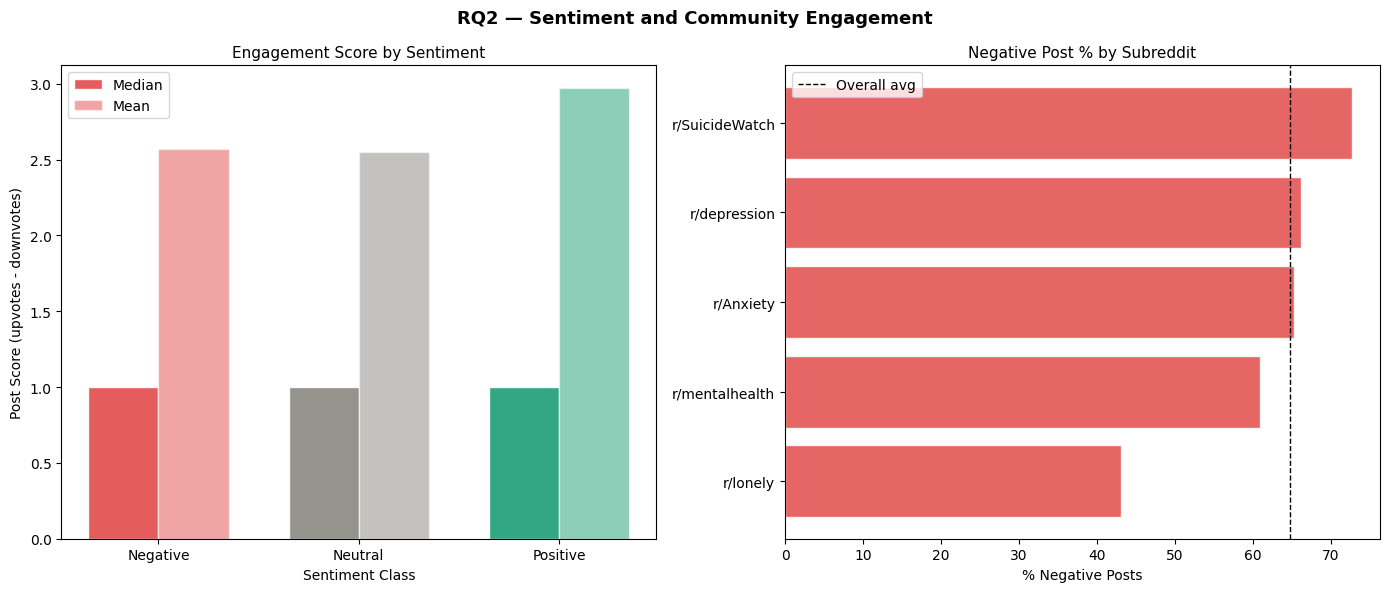

✓ Chart saved


In [12]:
# RQ2 Engagement Analysis
print("=== RQ2: ENGAGEMENT ANALYSIS ===\n")

engagement = df_results.groupby('vader_sentiment')['score'].agg([
    'count', 'mean', 'median'
]).round(2)
print("Engagement stats by sentiment:")
print(engagement)

neg = df_results[df_results['vader_sentiment'] == 'Negative']['score'].dropna()
neu = df_results[df_results['vader_sentiment'] == 'Neutral']['score'].dropna()
pos = df_results[df_results['vader_sentiment'] == 'Positive']['score'].dropna()

stat, p_value = stats.kruskal(neg, neu, pos)
print(f"\nKruskal-Wallis Test:")
print(f"H-statistic: {stat:.4f}")
print(f"P-value:     {p_value:.6f}")
print(f"Significant: {'Yes ✓' if p_value < 0.05 else 'No'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RQ2 — Sentiment and Community Engagement',
             fontsize=13, fontweight='bold')

sentiment_order = ['Negative', 'Neutral', 'Positive']
medians = [
    df_results[df_results['vader_sentiment'] == s]['score'].median()
    for s in sentiment_order
]
means = [
    df_results[df_results['vader_sentiment'] == s]['score'].mean()
    for s in sentiment_order
]

x = range(len(sentiment_order))
w = 0.35

axes[0].bar(
    [i - w/2 for i in x], medians, w, label='Median',
    color=['#E24B4A', '#888780', '#1D9E75'],
    edgecolor='white', alpha=0.9
)
axes[0].bar(
    [i + w/2 for i in x], means, w, label='Mean',
    color=['#E24B4A', '#888780', '#1D9E75'],
    edgecolor='white', alpha=0.5
)
axes[0].set_title('Engagement Score by Sentiment', fontsize=11)
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Post Score (upvotes - downvotes)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(sentiment_order)
axes[0].legend()

neg_pct = df_results.groupby('subreddit').apply(
    lambda x: (x['vader_sentiment'] == 'Negative').sum() / len(x) * 100
).sort_values()

axes[1].barh(
    [f"r/{s}" for s in neg_pct.index],
    neg_pct.values,
    color='#E24B4A', edgecolor='white', alpha=0.85
)
axes[1].set_title('Negative Post % by Subreddit', fontsize=11)
axes[1].set_xlabel('% Negative Posts')
axes[1].axvline(
    x=df_results['vader_sentiment'].eq('Negative').mean() * 100,
    color='black', linestyle='--',
    linewidth=1, label='Overall avg'
)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq2_engagement.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved")


In [13]:
# ── Score Part B with VADER ────────────────────────
print("Scoring Part B...")

scores_b = df_b['vader_text'].fillna('').apply(
    lambda x: analyzer.polarity_scores(str(x))
)
df_b['vader_compound']  = scores_b.apply(lambda x: x['compound'])
df_b['vader_neg']       = scores_b.apply(lambda x: x['neg'])
df_b['vader_pos']       = scores_b.apply(lambda x: x['pos'])
df_b['vader_sentiment'] = df_b['vader_compound'].apply(classify_sentiment)

print("Part B VADER complete")
print(f"\nSentiment distribution:")
print(df_b['vader_sentiment'].value_counts())
print(f"\nSentiment by label:")
print(pd.crosstab(df_b['Label'], df_b['vader_sentiment']))

# ── Save everything ────────────────────────────────
df_results.to_csv(SAVE_PATH + "vader_results.csv", index=False)
df_b.to_csv(SAVE_PATH + "vader_scored_part_b.csv", index=False)

print(f"\n✓ vader_results.csv saved")
print(f"✓ vader_scored_part_b.csv saved")

print("\n=== NOTEBOOK 03 COMPLETE ===")
print(f"Total posts: {df_results.shape[0]:,}")
print(f"Negative: {(df_results['vader_sentiment']=='Negative').sum():,} ({df_results['vader_sentiment'].value_counts(normalize=True)['Negative']*100:.1f}%)")
print(f"Positive: {(df_results['vader_sentiment']=='Positive').sum():,} ({df_results['vader_sentiment'].value_counts(normalize=True)['Positive']*100:.1f}%)")
print(f"Neutral:  {(df_results['vader_sentiment']=='Neutral').sum():,} ({df_results['vader_sentiment'].value_counts(normalize=True)['Neutral']*100:.1f}%)")
print("\nReady for Notebook 04 — BERT Fine-tuning")

Scoring Part B...
Part B VADER complete

Sentiment distribution:
vader_sentiment
Negative    605
Positive    191
Neutral       4
Name: count, dtype: int64

Sentiment by label:
vader_sentiment    Negative  Neutral  Positive
Label                                         
Drug and Alcohol        151        1        48
Early Life              162        0        38
Personality             151        1        48
Trauma and Stress       141        2        57

✓ vader_results.csv saved
✓ vader_scored_part_b.csv saved

=== NOTEBOOK 03 COMPLETE ===
Total posts: 1,412,786
Negative: 913,848 (64.7%)
Positive: 471,848 (33.4%)
Neutral:  27,090 (1.9%)

Ready for Notebook 04 — BERT Fine-tuning
